In [23]:
# @title
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import statsmodels.formula.api as smf

In [24]:
# @title
df = pd.read_excel("Pricing_Hof.xlsx")

In [25]:
df.head()

,ds,Product,units,sales,price,Weekday
0,2024-09-01,Latte,73.620000,247.770000,2.360000,Sunday
1,2024-09-01,Donuts,24.599448,56.464400,1.147676,Sunday
2,2024-09-01,Sandwich,15.593196,63.327502,5.279595,Sunday
3,2024-09-01,Bread,4.629108,12.211178,3.956867,Sunday
4,2024-09-01,Wings,30.389303,109.687264,3.248463,Sunday


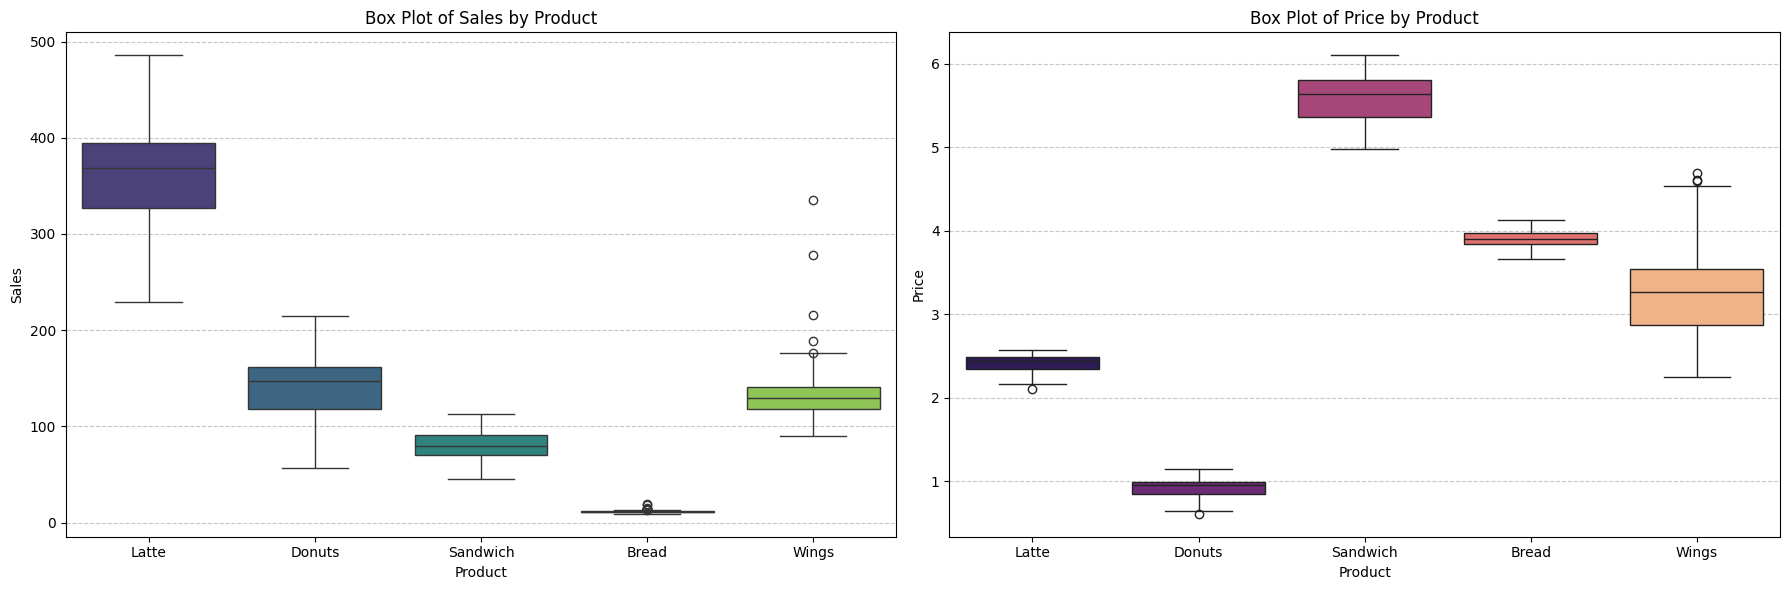

In [26]:
# @title
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Box Plot for Sales by Product
sns.boxplot(data=df, x='Product', y='sales', hue='Product', palette='viridis', legend=False, ax=axes[0])
axes[0].set_title('Box Plot of Sales by Product')
axes[0].set_xlabel('Product')
axes[0].set_ylabel('Sales')
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Box Plot for Price by Product
sns.boxplot(data=df, x='Product', y='price', hue='Product', palette='magma', legend=False, ax=axes[1])
axes[1].set_title('Box Plot of Price by Product')
axes[1].set_xlabel('Product')
axes[1].set_ylabel('Price')
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [27]:
print("Calculating IQR and Outliers for Sales and Price by Product:")
for product in df['Product'].unique():
    df_product = df[df['Product'] == product]

    print(f"\n--- Product: {product} ---")

    # --- Sales Outlier Calculation ---
    Q1_sales = df_product['sales'].quantile(0.25)
    Q3_sales = df_product['sales'].quantile(0.75)
    IQR_sales = Q3_sales - Q1_sales
    upper_bound_sales = Q3_sales + 1.5 * IQR_sales
    lower_bound_sales = Q1_sales - 1.5 * IQR_sales
    outliers_sales_count = df_product[(df_product['sales'] < lower_bound_sales) | (df_product['sales'] > upper_bound_sales)].shape[0]

    print(f"Sales:")
    print(f"  IQR: {IQR_sales:.2f}")
    print(f"  Number of outliers: {outliers_sales_count}")
    print(f"  Lower bound: {lower_bound_sales:.2f}")
    print(f"  Upper bound: {upper_bound_sales:.2f}")

    # --- Price Outlier Calculation ---
    Q1_price = df_product['price'].quantile(0.25)
    Q3_price = df_product['price'].quantile(0.75)
    IQR_price = Q3_price - Q1_price
    upper_bound_price = Q3_price + 1.5 * IQR_price
    lower_bound_price = Q1_price - 1.5 * IQR_price
    outliers_price_count = df_product[(df_product['price'] < lower_bound_price) | (df_product['price'] > upper_bound_price)].shape[0]

    print(f"Price:")
    print(f"  IQR: {IQR_price:.2f}")
    print(f"  Number of outliers: {outliers_price_count}")
    print(f"  Lower bound: {lower_bound_price:.2f}")
    print(f"  Upper bound: {upper_bound_price:.2f}")

Calculating IQR and Outliers for Sales and Price by Product:

--- Product: Latte ---
Sales:
  IQR: 67.87
  Number of outliers: 0
  Lower bound: 224.84
  Upper bound: 496.33
Price:
  IQR: 0.15
  Number of outliers: 1
  Lower bound: 2.11
  Upper bound: 2.72

--- Product: Donuts ---
Sales:
  IQR: 43.70
  Number of outliers: 0
  Lower bound: 52.32
  Upper bound: 227.11
Price:
  IQR: 0.14
  Number of outliers: 1
  Lower bound: 0.64
  Upper bound: 1.20

--- Product: Sandwich ---
Sales:
  IQR: 20.65
  Number of outliers: 0
  Lower bound: 38.94
  Upper bound: 121.53
Price:
  IQR: 0.44
  Number of outliers: 0
  Lower bound: 4.71
  Upper bound: 6.46

--- Product: Bread ---
Sales:
  IQR: 1.18
  Number of outliers: 10
  Lower bound: 8.65
  Upper bound: 13.36
Price:
  IQR: 0.13
  Number of outliers: 0
  Lower bound: 3.65
  Upper bound: 4.16

--- Product: Wings ---
Sales:
  IQR: 23.56
  Number of outliers: 5
  Lower bound: 82.31
  Upper bound: 176.53
Price:
  IQR: 0.67
  Number of outliers: 3
  Lowe

In [28]:
# @title
df['month'] = df['ds'].dt.month_name()

In [29]:
df.head(10)

,ds,Product,units,sales,price,Weekday,month
0,2024-09-01,Latte,73.620000,247.770000,2.360000,Sunday,September
1,2024-09-01,Donuts,24.599448,56.464400,1.147676,Sunday,September
2,2024-09-01,Sandwich,15.593196,63.327502,5.279595,Sunday,September
3,2024-09-01,Bread,4.629108,12.211178,3.956867,Sunday,September
4,2024-09-01,Wings,30.389303,109.687264,3.248463,Sunday,September
5,2024-09-02,Wings,44.165066,129.008443,2.628947,Monday,September
6,2024-09-02,Bread,4.136784,10.606396,3.845884,Monday,September
7,2024-09-02,Sandwich,19.169287,76.374502,5.179475,Monday,September
8,2024-09-02,Donuts,59.423517,116.900127,0.983618,Monday,September
9,2024-09-02,Latte,116.210000,388.750000,2.340000,Monday,September


In [30]:
# @title
monthly_product_sales = df.groupby(['month', 'Product'])['units'].sum().reset_index()

# Defining the chronological order for months (Sept 2024 - Aug 2025)
month_order = ['September', 'October', 'November', 'December', 'January', 'February', 'March', 'April', 'May', 'June', 'July', 'August']

# Convert 'month' to a categorical type with the defined order
monthly_product_sales['month'] = pd.Categorical(monthly_product_sales['month'], categories=month_order, ordered=True)

# Sort the DataFrame by the ordered 'month' column
monthly_product_sales = monthly_product_sales.sort_values('month')

In [31]:
monthly_product_sales

,month,Product,units
59,September,Wings,1277.777127
57,September,Latte,3439.860000
56,September,Donuts,1793.415629
55,September,Bread,134.519623
58,September,Sandwich,527.869191
54,October,Wings,1076.402198
53,October,Sandwich,465.357114
52,October,Latte,3032.060000
51,October,Donuts,1947.325018
50,October,Bread,114.666166


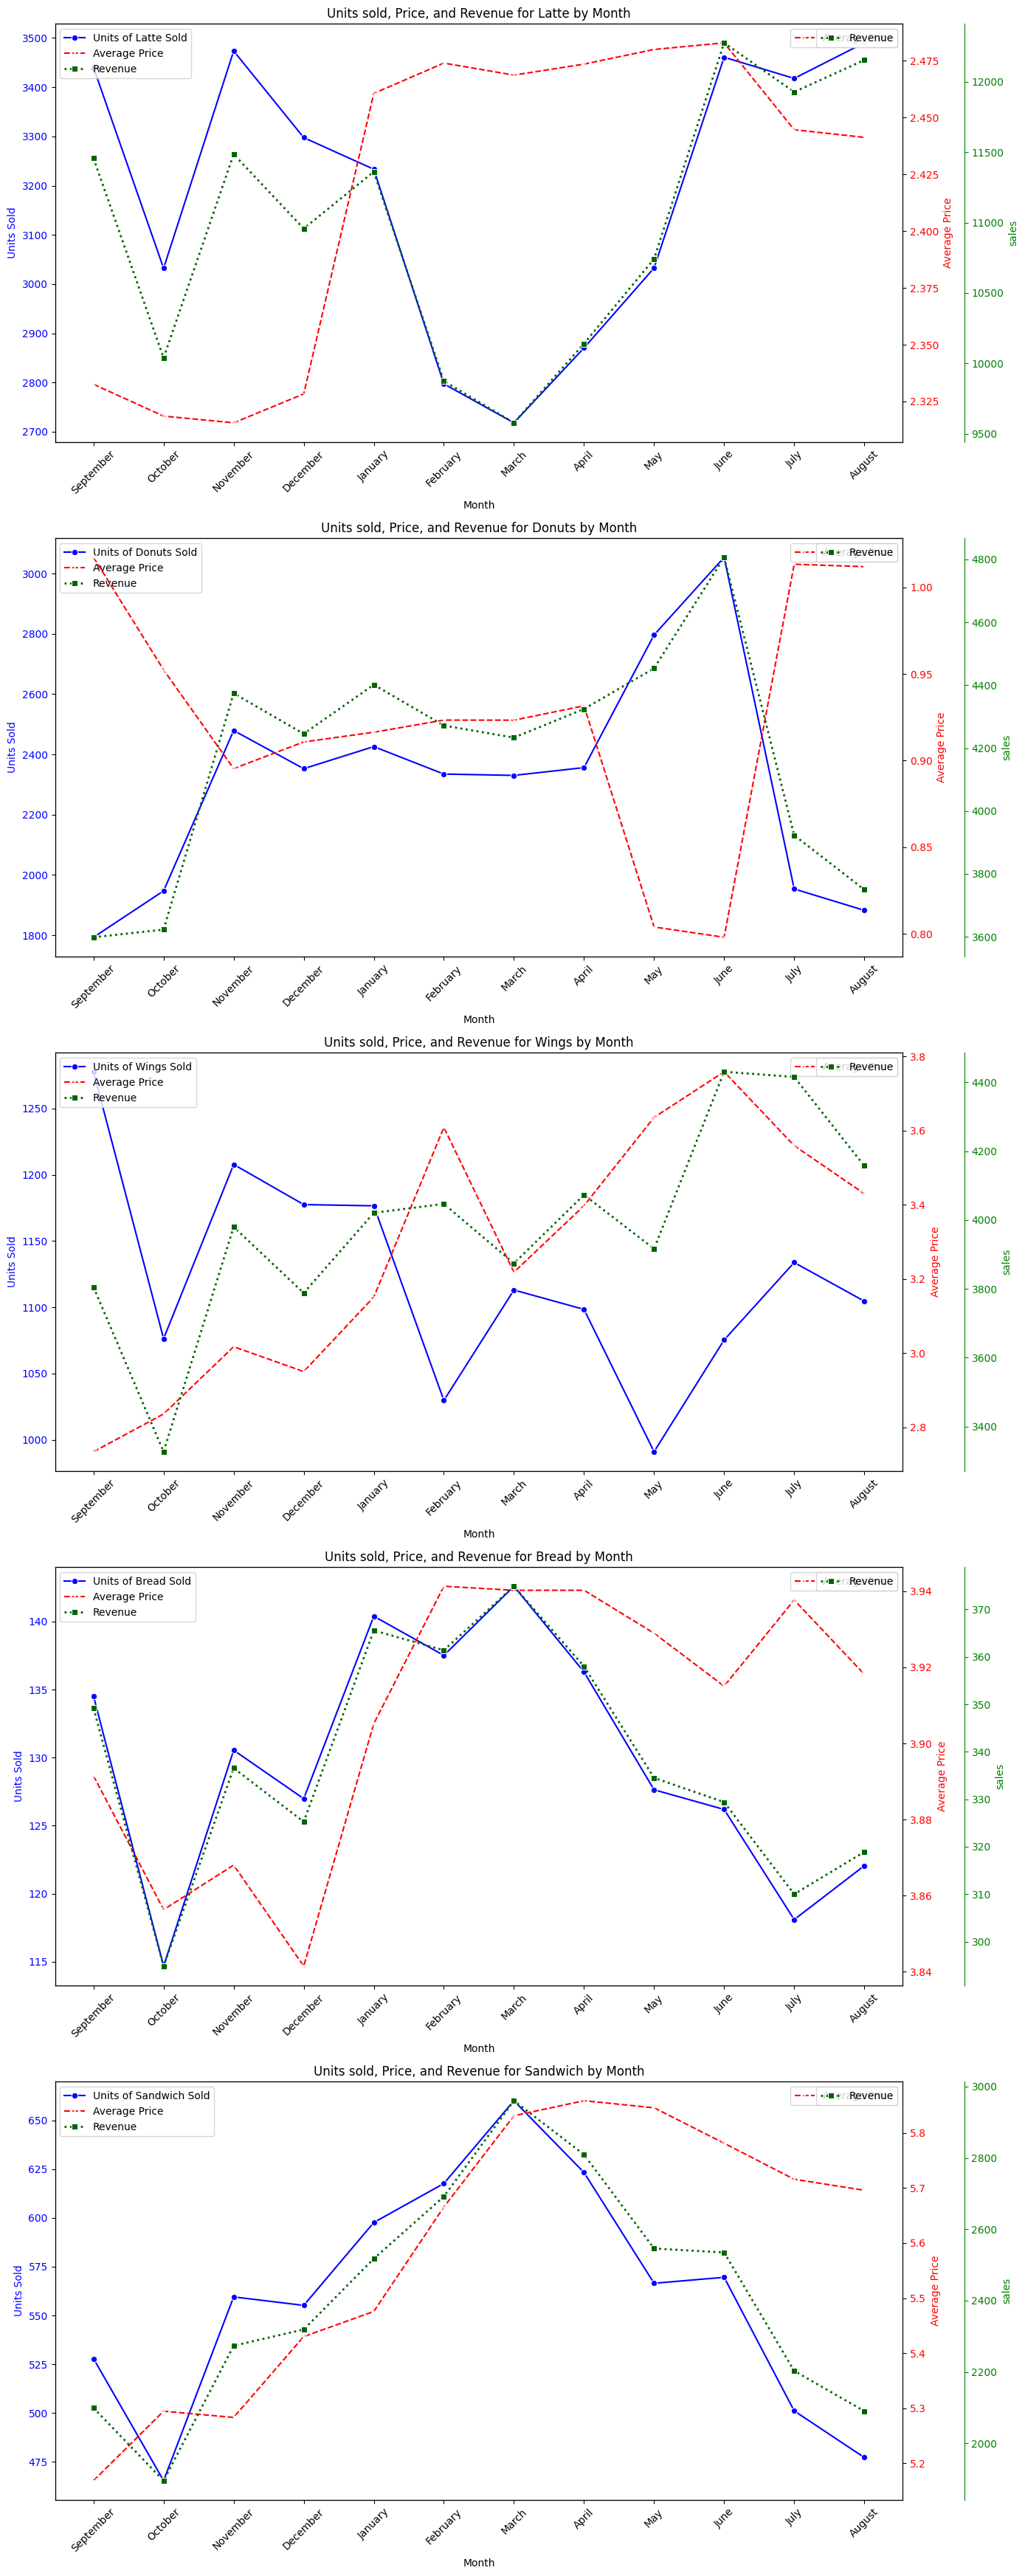

In [32]:
products_to_analyze = ['Latte', 'Donuts', 'Wings', 'Bread', 'Sandwich']

# Reload the original DataFrame to ensure all products are available
#df = pd.read_excel("Pricing_Hof.xlsx")

# Ensure 'ds' is datetime for the main DataFrame
#df['ds'] = pd.to_datetime(df['ds'])

fig, axes = plt.subplots(len(products_to_analyze), 1, figsize=(14, 7 * len(products_to_analyze)))

for i, product_name in enumerate(products_to_analyze):
    # Select the correct subplot axis
    ax1 = axes[i]

    # Filter for the current product
    df_product_monthly = df[df['Product'] == product_name].copy()
    df_product_monthly_donuts = df[df['Product'] == "Donuts"].copy()



    # Aggregate by month
    monthly_trends_product = df_product_monthly.groupby(['month']).agg(
        units=('units', 'sum'),
        avg_price=('price', 'mean'),
        sales=('sales', 'sum') # Add average sales
    ).reset_index()
    df_product_monthly_donuts = df_product_monthly_donuts.groupby(['month']).agg(
        units=('units', 'sum')).reset_index()

    month_order = ['September', 'October', 'November', 'December', 'January', 'February', 'March', 'April', 'May', 'June', 'July', 'August']

# Convert 'month' to a categorical type with the defined order
    monthly_trends_product['month'] = pd.Categorical(monthly_trends_product['month'], categories=month_order, ordered=True)
    df_product_monthly_donuts['month'] = pd.Categorical(df_product_monthly_donuts['month'], categories=month_order, ordered=True)

    # Sort by day of the week numerically for correct plotting order
    monthly_trends_product = monthly_trends_product.sort_values('month')
    df_product_monthly_donuts = df_product_monthly_donuts.sort_values('month')


    # Plotting Units sold per month
    sns.lineplot(x='month', y='units', data=monthly_trends_product, marker='o', ax=ax1, color='blue', label=f'Units of {product_name} Sold')
    #sns.lineplot(x='month', y='units', data=df_product_monthly_donuts, marker='o', ax=ax1, color='pink', label='Donuts Units Sold')
    ax1.set_xlabel('Month')
    ax1.set_ylabel('Units Sold', color='blue')
    ax1.tick_params(axis='y', labelcolor='blue')
    #ax1.grid(True, linestyle='--', alpha=0.7)

    # Create a second y-axis for Average Price
    ax2 = ax1.twinx()
    sns.lineplot(x='month', y='avg_price', data=monthly_trends_product, marker='x', ax=ax2, color='red', linestyle='--', label='Average Price')
    ax2.set_ylabel('Average Price', color='red')
    ax2.tick_params(axis='y', labelcolor='red')

    # Create a third y-axis for Average Revenue
    ax3 = ax1.twinx()
    ax3.spines['right'].set_position(('outward', 60))
    ax3.spines['right'].set_color('green')
    ax3.yaxis.label.set_color('green')
    ax3.tick_params(axis='y', colors='green')
    sns.lineplot(x='month', y='sales', data=monthly_trends_product, marker='s', ax=ax3, color='darkgreen', linestyle=':', linewidth=2, label='Revenue')
   ## ax3.set_ylabel('Revenue', color='green')

    ax1.set_title(f'Units sold, Price, and Revenue for {product_name} by Month')
    ax1.tick_params(axis='x', rotation=45)

    # Combine legends from all axes for the current subplot
    handles1, labels1 = ax1.get_legend_handles_labels()
    handles2, labels2 = ax2.get_legend_handles_labels()
    handles3, labels3 = ax3.get_legend_handles_labels()
    ax1.legend(handles1 + handles2 + handles3, labels1 + labels2 + labels3, loc='upper left')

plt.tight_layout()
plt.savefig('monthly_units_price_revenue_plot.png')
plt.show()

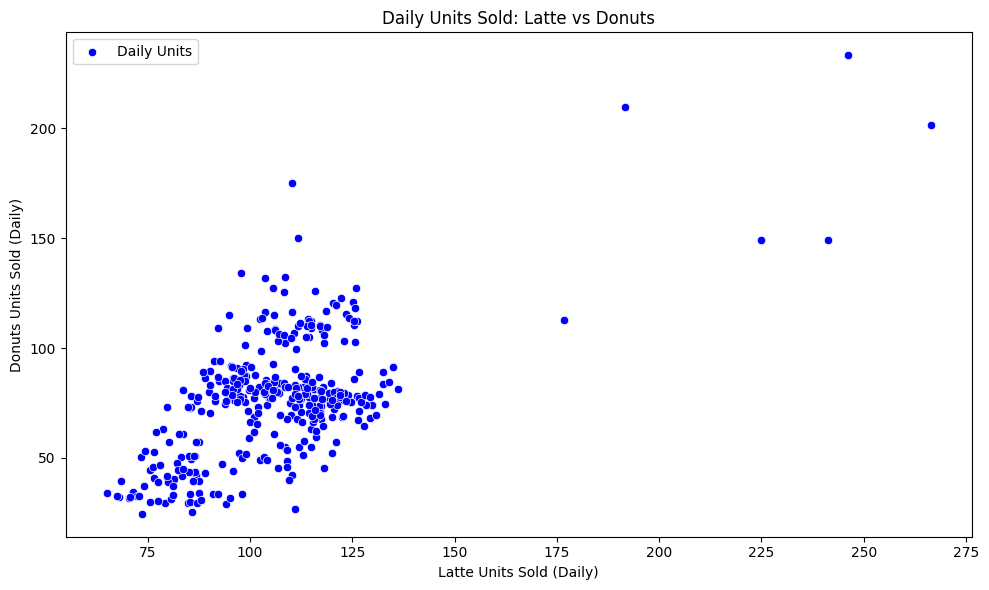

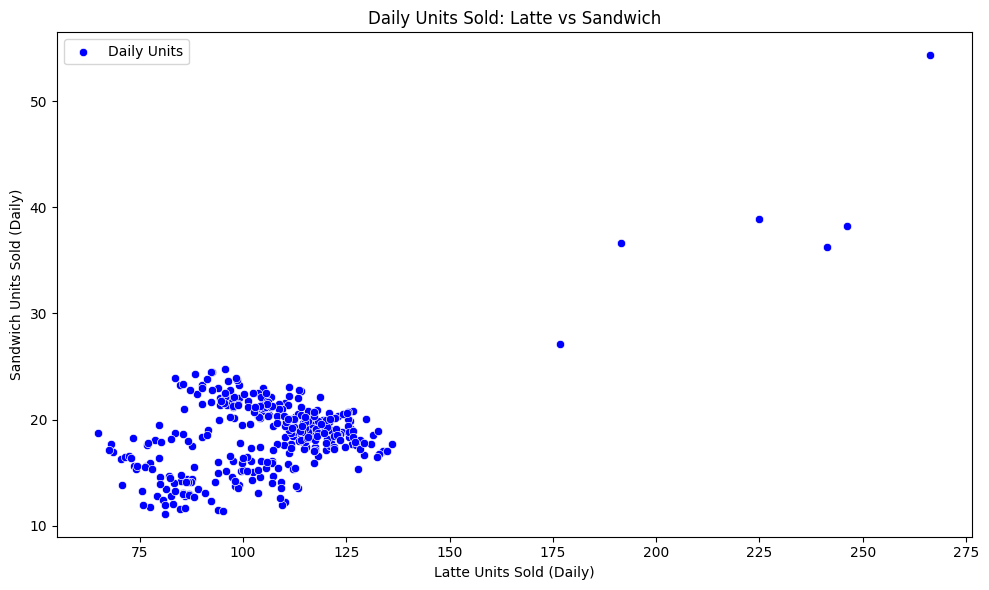

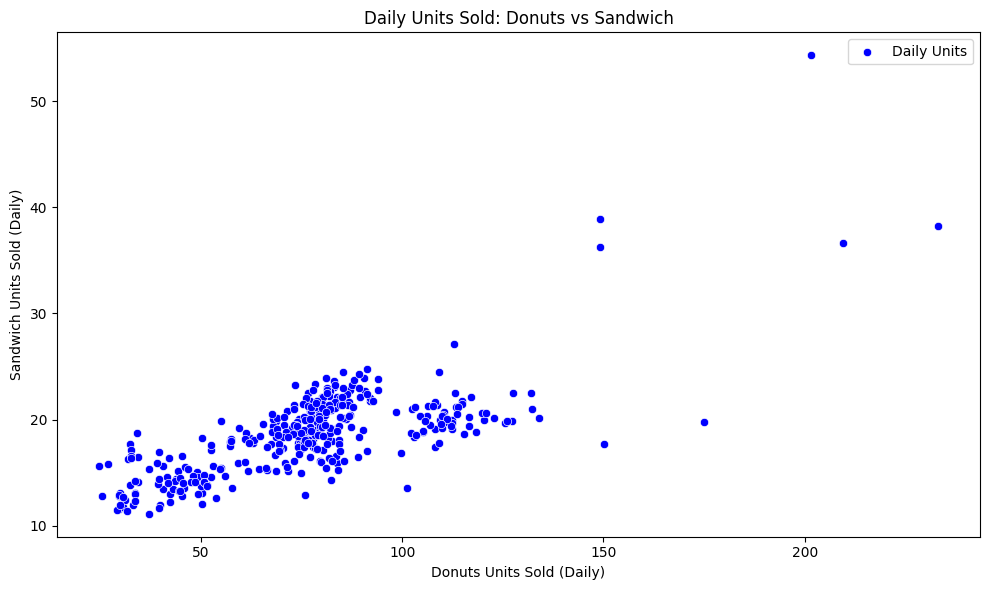

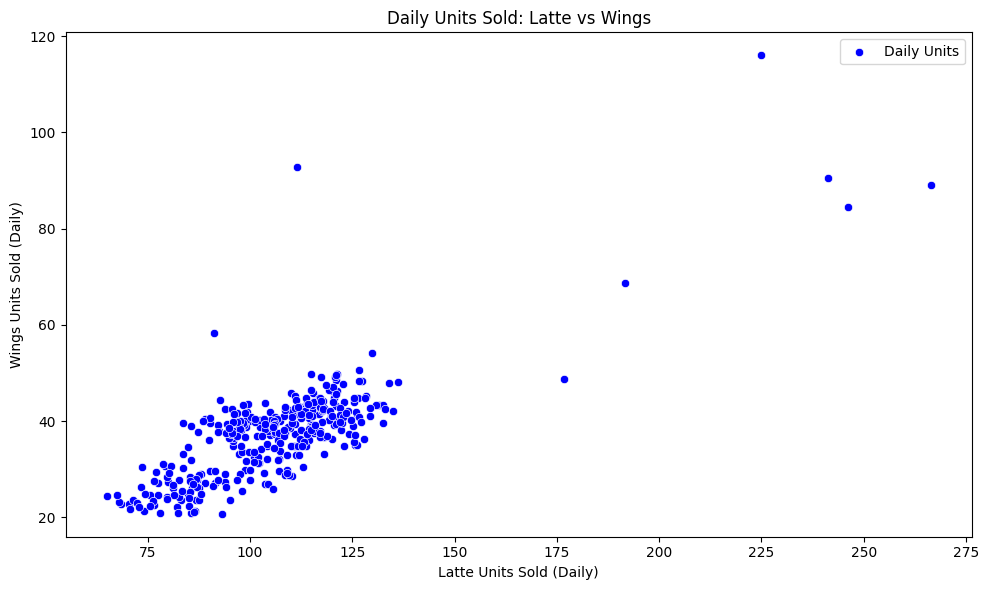

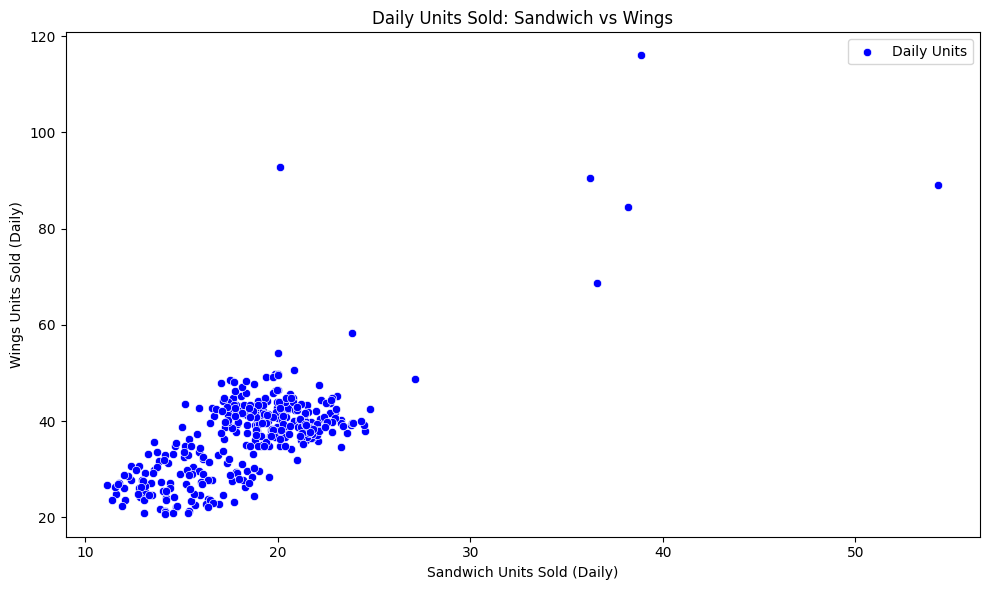

In [33]:
# Reload the original DataFrame to ensure all products are available
df = pd.read_excel("Pricing_Hof.xlsx")

# Ensure 'ds' is datetime (if not already)
df['ds'] = pd.to_datetime(df['ds'])

# Define the pairs of products for which to create scatter plots
product_pairs = [
    ('Latte', 'Donuts'),
    ('Latte', 'Sandwich'),
    ('Donuts', 'Sandwich'),
    ('Latte', 'Wings'),
    ('Sandwich', 'Wings')
]

for product1, product2 in product_pairs:
    # Filter for the two products in the current pair
    df_filtered_products = df[df['Product'].isin([product1, product2])]

    # Aggregate by 'ds' (daily) and Product for daily units sold
    daily_product_sales = df_filtered_products.groupby(['ds', 'Product'])['units'].sum().reset_index()

    # Pivot the DataFrame to get units of each product as separate columns
    pivot_daily_sales = daily_product_sales.pivot(index='ds', columns='Product', values='units').reset_index()
    pivot_daily_sales.columns.name = None # Clean up the column index name

    # Rename columns for clarity in plotting
    col1 = f'units_{product1.lower()}'
    col2 = f'units_{product2.lower()}'
    pivot_daily_sales = pivot_daily_sales.rename(columns={product1: col1, product2: col2})

    # Create a new figure and axes for the scatter plot
    plt.figure(figsize=(10, 6))
    ax = sns.scatterplot(x=col1, y=col2, data=pivot_daily_sales, marker='o', color='blue', label='Daily Units')
    ax.set_xlabel(f'{product1} Units Sold (Daily)')
    ax.set_ylabel(f'{product2} Units Sold (Daily)')
    ax.set_title(f'Daily Units Sold: {product1} vs {product2}')
    ax.legend()
    plt.tight_layout()
    plt.savefig(f'daily_units_scatter_plot_{product1.lower()}_vs_{product2.lower()}.png')
    plt.show()


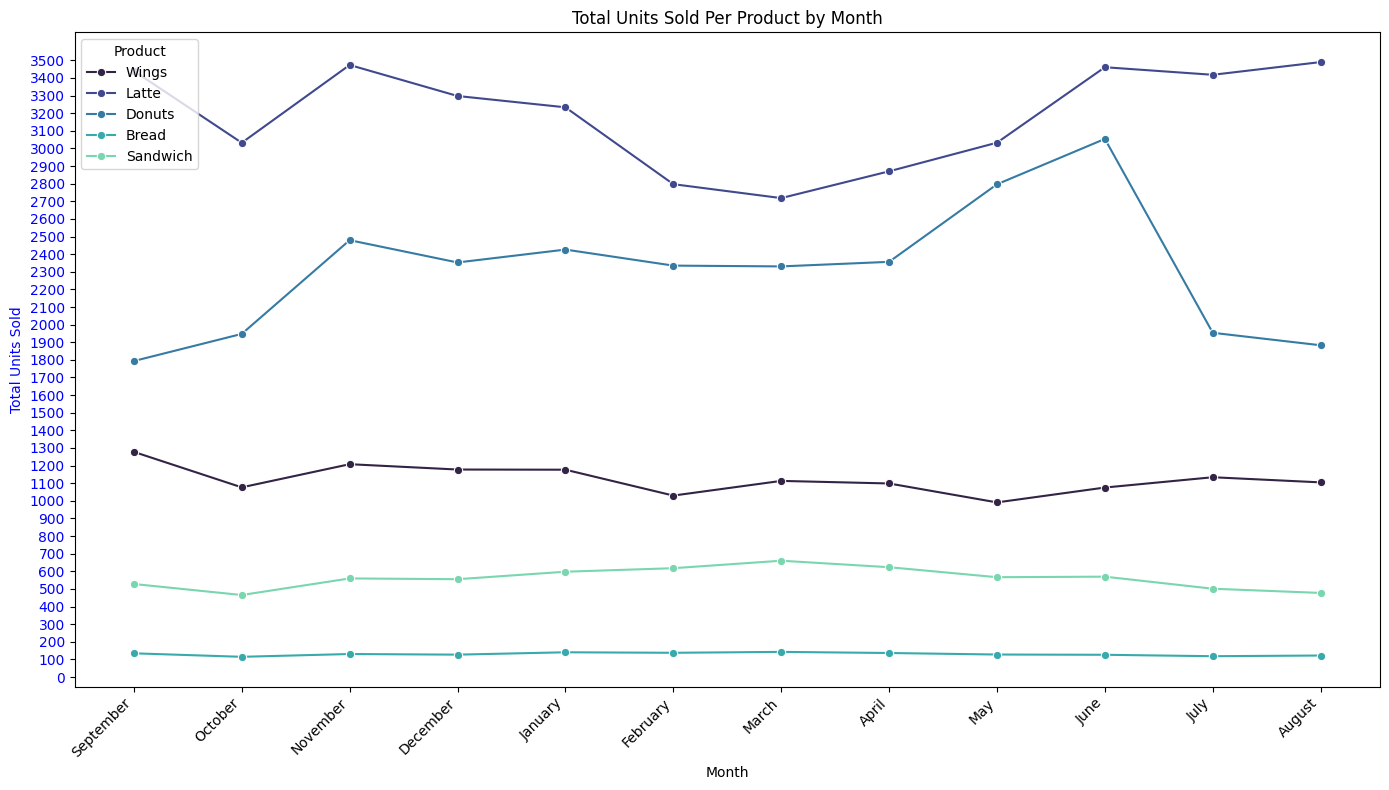

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure 'ds' column is datetime and create 'month' column
df['ds'] = pd.to_datetime(df['ds'])
df['month'] = df['ds'].dt.month_name()

# Calculate average monthly price for each product
monthly_product_price = df.groupby(['month', 'Product'])['price'].mean().reset_index()
monthly_product_price = monthly_product_price.rename(columns={'price': 'avg_price'})

# Merge units sold and average price data
monthly_product_stats = pd.merge(monthly_product_sales, monthly_product_price, on=['month', 'Product'])

# Defining the chronological order for months (Sept 2024 - Aug 2025) if not already defined
month_order = ['September', 'October', 'November', 'December', 'January', 'February', 'March', 'April', 'May', 'June', 'July', 'August']

# Convert 'month' to a categorical type with the defined order
monthly_product_stats['month'] = pd.Categorical(monthly_product_stats['month'], categories=month_order, ordered=True)

# Sort the DataFrame by the ordered 'month' column
monthly_product_stats = monthly_product_stats.sort_values('month')

plt.figure(figsize=(14, 8))

# First Y-axis for Total Units Sold
ax1 = sns.lineplot(data=monthly_product_stats, x='month', y='units', hue='Product', marker='o', palette='mako', legend='full')
ax1.set_title('Total Units Sold Per Product by Month')
ax1.set_xlabel('Month')
ax1.set_ylabel('Total Units Sold', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.set_xticks(range(len(month_order)))
ax1.set_xticklabels(month_order, rotation=45, ha='right')
ax1.grid(False)


# Combine legends from both axes
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
# Filter out duplicate labels for 'Product'
by_label = dict(zip(labels1, handles1))
ax1.legend(by_label.values(), by_label.keys(), title='Product', loc='upper left')

# Get the maximum units sold to determine the upper limit for y-ticks on ax1
max_units = monthly_product_stats['units'].max()
plt.yticks(np.arange(0, max_units + 100, 100))

plt.tight_layout()
plt.savefig('total_units_sold_per_product_by_month.png')
plt.show()

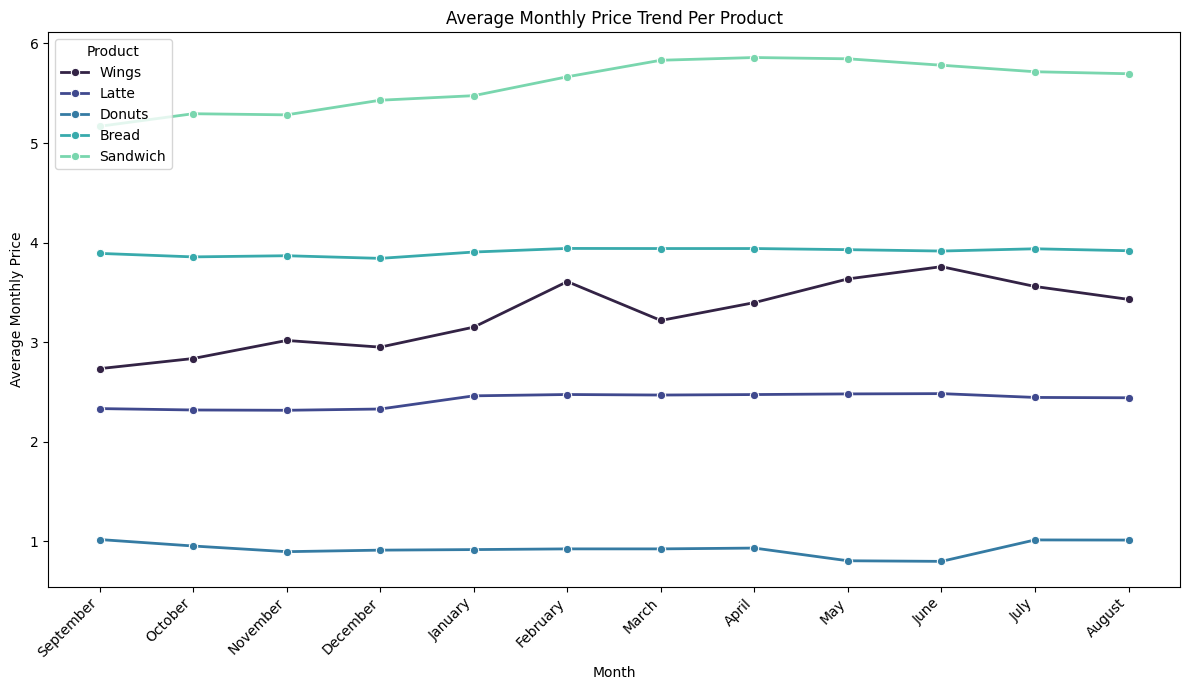

In [13]:
plt.figure(figsize=(12, 7))
sns.lineplot(data=monthly_product_stats, x='month', y='avg_price', hue='Product', marker='o', palette='mako', linewidth=2)
plt.title('Average Monthly Price Trend Per Product')
plt.xlabel('Month')
plt.ylabel('Average Monthly Price')
plt.xticks(rotation=45, ha='right')
#plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Product', loc='upper left')
plt.tight_layout()
plt.savefig('average_monthly_price_trend.png')
plt.show()

### Weekly Trend Analysis for Latte, Donuts and Wings

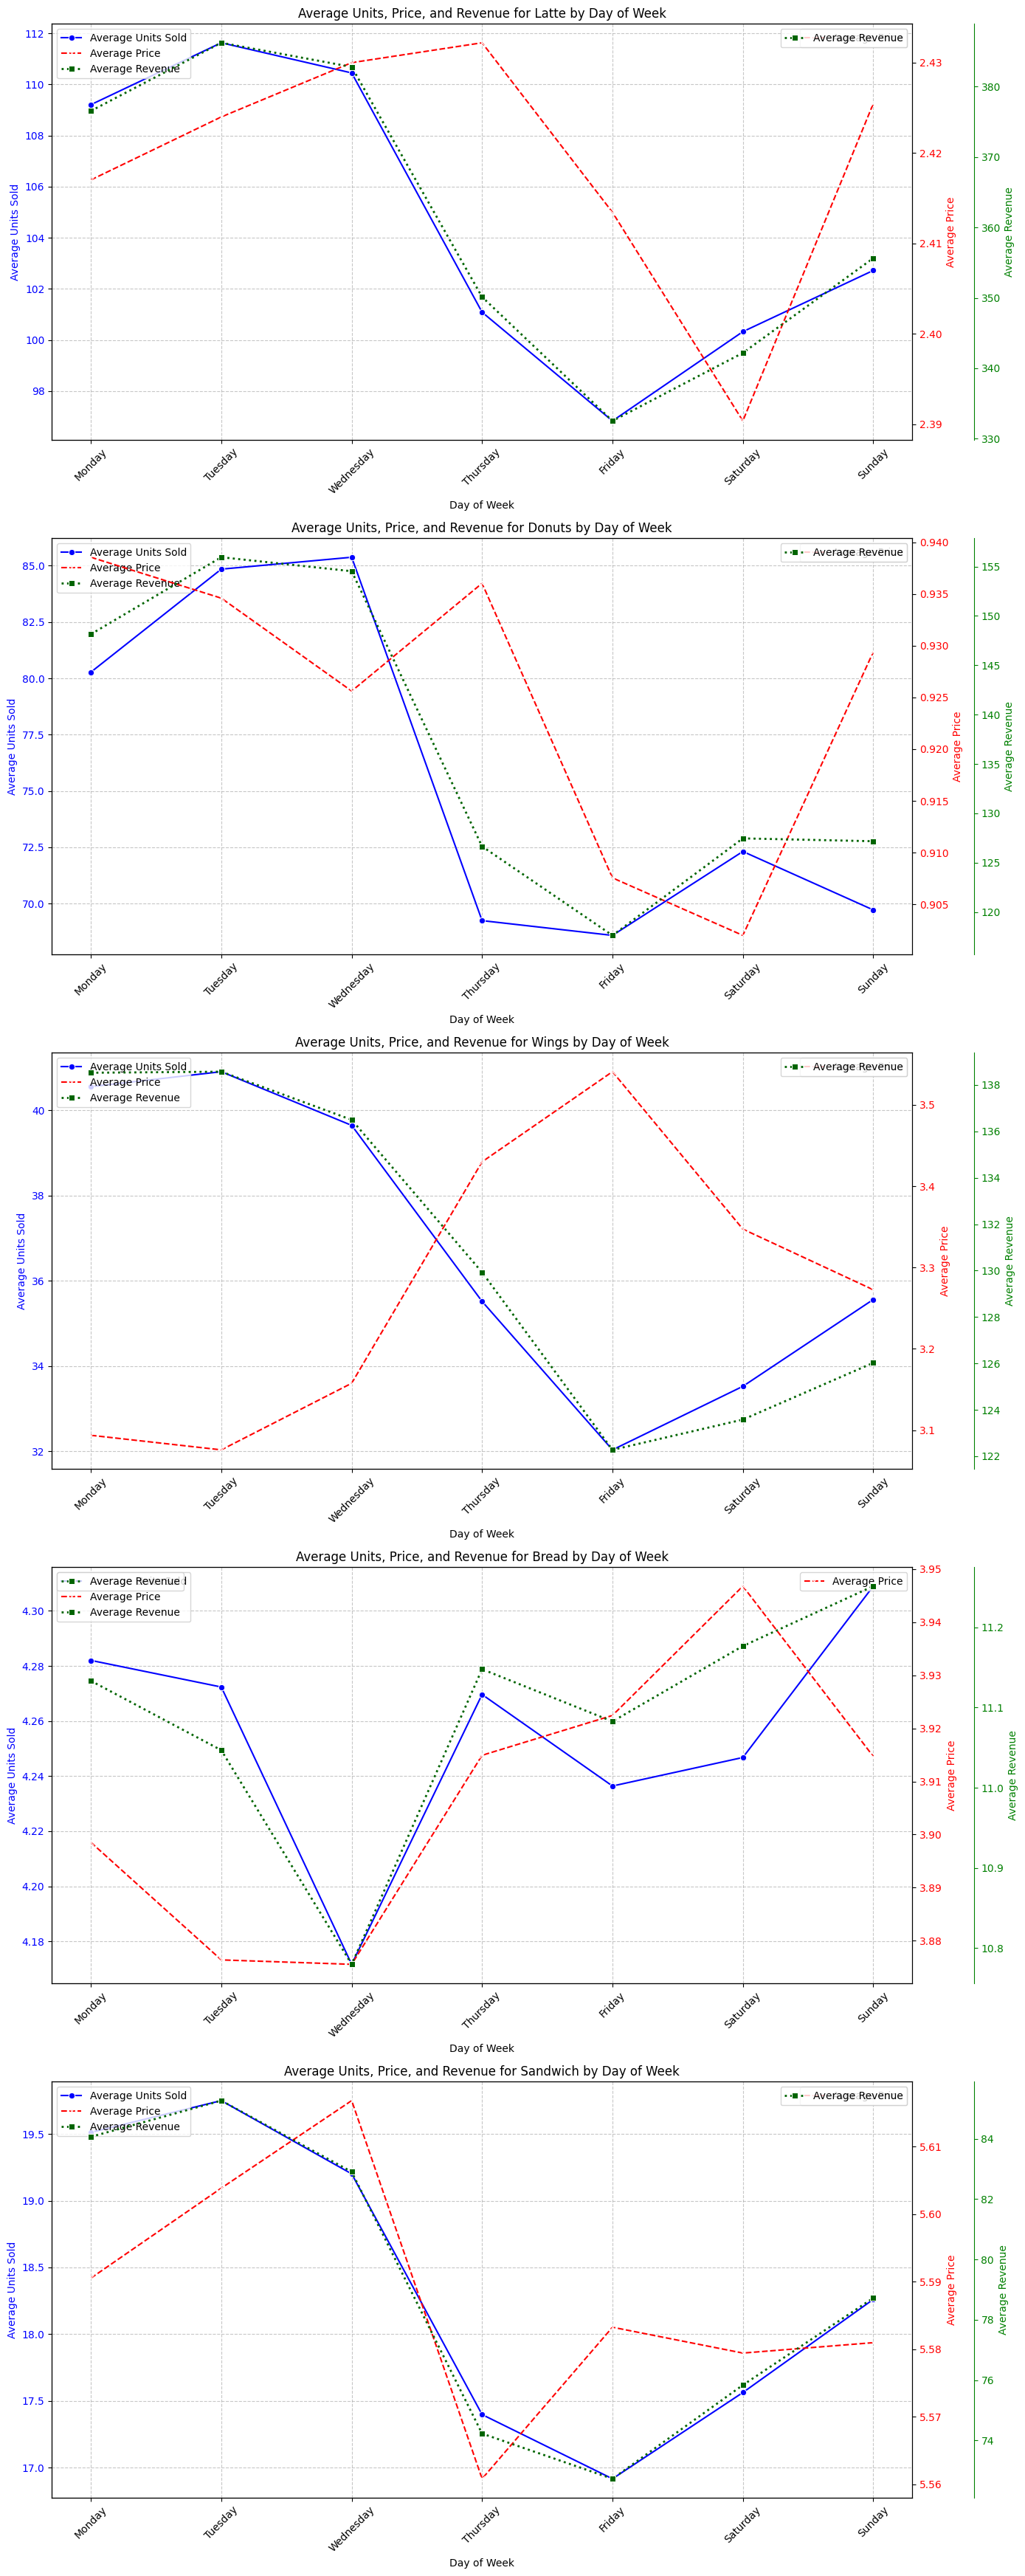

In [14]:
# @title
products_to_analyze = ['Latte', 'Donuts', 'Wings', 'Bread', 'Sandwich']

# Reload the original DataFrame to ensure all products are available
df = pd.read_excel("Pricing_Hof.xlsx")

# Ensure 'ds' is datetime for the main DataFrame
df['ds'] = pd.to_datetime(df['ds'])

fig, axes = plt.subplots(len(products_to_analyze), 1, figsize=(14, 7 * len(products_to_analyze)))

for i, product_name in enumerate(products_to_analyze):
    # Select the correct subplot axis
    ax1 = axes[i]

    # Filter for the current product
    df_product_weekly = df[df['Product'] == product_name].copy()

    # Extract day of the week (Monday=0, Sunday=6)
    df_product_weekly['day_of_week_num'] = df_product_weekly['ds'].dt.weekday
    df_product_weekly['day_of_week_name'] = df_product_weekly['ds'].dt.day_name()

    # Aggregate by day of the week
    weekly_trends_product = df_product_weekly.groupby(['day_of_week_num', 'day_of_week_name']).agg(
        avg_units=('units', 'mean'),
        avg_price=('price', 'mean'),
        avg_sales=('sales', 'mean') # Add average sales
    ).reset_index()

    # Sort by day of the week numerically for correct plotting order
    weekly_trends_product = weekly_trends_product.sort_values('day_of_week_num')

    # Plotting Average Units by Day of Week on the first y-axis
    sns.lineplot(x='day_of_week_name', y='avg_units', data=weekly_trends_product, marker='o', ax=ax1, color='blue', label='Average Units Sold')
    ax1.set_xlabel('Day of Week')
    ax1.set_ylabel('Average Units Sold', color='blue')
    ax1.tick_params(axis='y', labelcolor='blue')
    ax1.grid(True, linestyle='--', alpha=0.7)

    # Create a second y-axis for Average Price
    ax2 = ax1.twinx()
    sns.lineplot(x='day_of_week_name', y='avg_price', data=weekly_trends_product, marker='x', ax=ax2, color='red', linestyle='--', label='Average Price')
    ax2.set_ylabel('Average Price', color='red')
    ax2.tick_params(axis='y', labelcolor='red')

    # Create a third y-axis for Average Revenue
    ax3 = ax1.twinx()
    ax3.spines['right'].set_position(('outward', 60)) # Offset the right spine to make room for the third y-axis
    ax3.spines['right'].set_color('green') # Make the spine match the line color
    ax3.yaxis.label.set_color('green')
    ax3.tick_params(axis='y', colors='green')
    sns.lineplot(x='day_of_week_name', y='avg_sales', data=weekly_trends_product, marker='s', ax=ax3, color='darkgreen', linestyle=':', linewidth=2, label='Average Revenue')
    ax3.set_ylabel('Average Revenue', color='green')

    ax1.set_title(f'Average Units, Price, and Revenue for {product_name} by Day of Week')
    ax1.tick_params(axis='x', rotation=45)

    # Combine legends from all axes for the current subplot
    handles1, labels1 = ax1.get_legend_handles_labels()
    handles2, labels2 = ax2.get_legend_handles_labels()
    handles3, labels3 = ax3.get_legend_handles_labels()
    ax1.legend(handles1 + handles2 + handles3, labels1 + labels2 + labels3, loc='upper left')

plt.tight_layout()
plt.savefig('weekly_units_price_revenue_plot.png')
plt.show()

### Daily Time Series of Units and Price for Latte

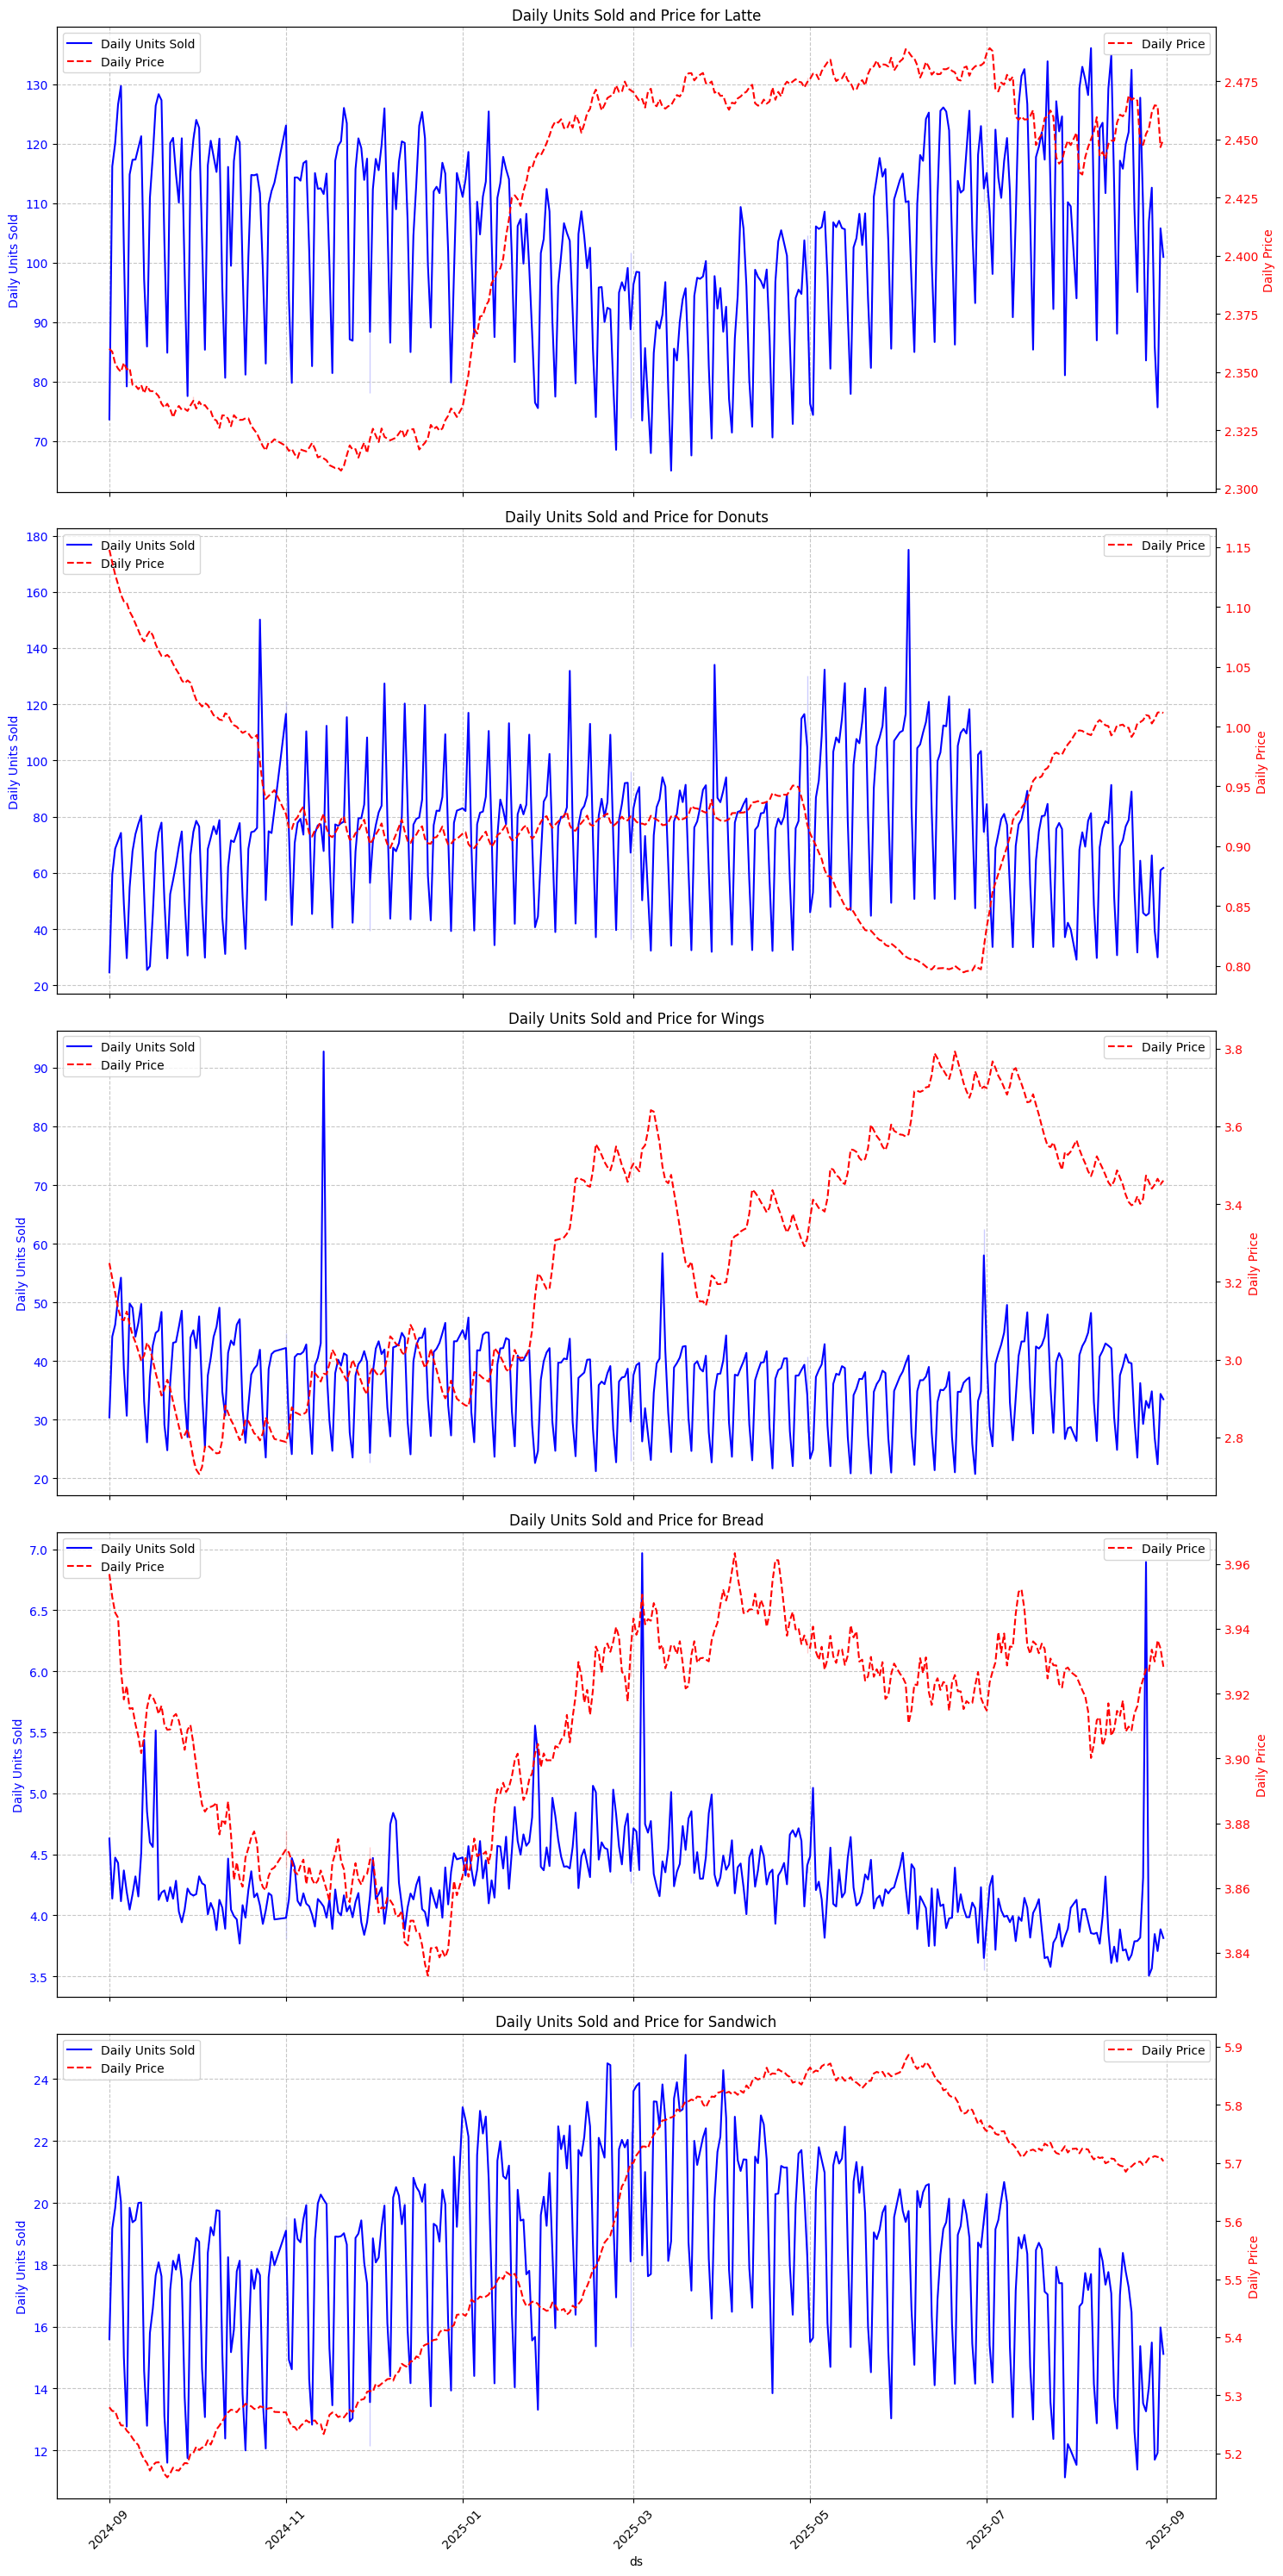

In [15]:
# @title
products_to_plot = ['Latte', 'Donuts', 'Wings', 'Bread', 'Sandwich']

# Ensure 'ds' column is datetime for the main DataFrame
df['ds'] = pd.to_datetime(df['ds'])

fig, axes = plt.subplots(len(products_to_plot), 1, figsize=(15, 6 * len(products_to_plot)), sharex=True)

for i, product_name in enumerate(products_to_plot):
    ax1 = axes[i]

    # Filter for the current product
    df_product_daily = df[df['Product'] == product_name].copy()

    # Sort by date for proper time series plotting
    df_product_daily = df_product_daily.sort_values('ds')

    # --- Price Cleaning and Smoothing (as done in previous cells) ---
    z = (df_product_daily['price'] - df_product_daily['price'].mean()) / df_product_daily['price'].std()
    df_product_daily['price_clean'] = df_product_daily['price'].where(abs(z) < 3)
    df_product_daily['price_clean'] = df_product_daily['price_clean'].interpolate()
    df_product_daily['price_smooth'] = df_product_daily['price_clean'].ewm(span=30, adjust=False).mean()

    # Plotting Daily Units on the first y-axis
    sns.lineplot(x='ds', y='units', data=df_product_daily, ax=ax1, color='blue', label='Daily Units Sold')
    ax1.set_ylabel('Daily Units Sold', color='blue')
    ax1.tick_params(axis='y', labelcolor='blue')
    ax1.grid(True, linestyle='--', alpha=0.7)

    # Create a second y-axis for Daily Price
    ax2 = ax1.twinx()
    sns.lineplot(x='ds', y='price_smooth', data=df_product_daily, ax=ax2, color='red', linestyle='--', label='Daily Price')
    ax2.set_ylabel('Daily Price', color='red')
    ax2.tick_params(axis='y', labelcolor='red')

    ax1.set_title(f'Daily Units Sold and Price for {product_name}')
    ax1.tick_params(axis='x', rotation=45)

    # Combine legends from both axes
    handles1, labels1 = ax1.get_legend_handles_labels()
    handles2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(handles1 + handles2, labels1 + labels2, loc='upper left')

plt.xlabel('Date') # Set a common x-label for the last subplot
plt.tight_layout()

# Save the figure to a file
plt.savefig('daily_units_price_plot.png')

plt.show()

In [16]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf

# Reload the original DataFrame to ensure it's not empty
df_original = pd.read_excel("Pricing_Hof.xlsx")

# Define training window
start_date = "09-01-2024"
end_date = "05-31-2025"

# Filter df_original for the training window
df_filtered_date = df_original[(df_original["ds"] >= start_date) & (df_original["ds"] <= end_date)].copy()

all_product_elasticities = {}

for product_name in df_filtered_date["Product"].unique():
    df = df_filtered_date[df_filtered_date["Product"] == product_name].copy()

    if len(df) < 2: # Ensure enough data points for regression
        print(f"Skipping {product_name}: Not enough data points in the specified date range.")
        continue

    df["ds"] = pd.to_datetime(df["ds"])
    df = df.sort_values("ds").reset_index(drop=True)

    # 2. Price cleaning + smoothing
    z = (df["price"] - df["price"].mean()) / df["price"].std()
    df["price_clean"] = df["price"].where(abs(z) < 3)
    df["price_clean"] = df["price_clean"].interpolate(limit_direction='both') # Interpolate both ways

    # Check if price_clean still has NaNs after interpolation (e.g., all NaNs)
    if df['price_clean'].isnull().all():
        print(f"Skipping {product_name}: All prices are NaN after cleaning.")
        continue

    # 3. Log transforms
    # Handle potential non-positive values before log transformation
    if (df["units"] <= 0).any() or (df["price_clean"] <= 0).any():
        print(f"Skipping {product_name}: Contains non-positive 'units' or 'price_clean' for log transformation.")
        continue

    df["ln_units"] = np.log(df["units"])
    df["ln_price"] = np.log(df["price_clean"])

    # 4. Weekend indicator
    df["is_weekend"] = df["ds"].dt.weekday.isin([5,6]).astype(int)

    # 5. Holiday indicator (simple version)
    df["is_holiday"] = 0 # You can customize holidays later

    # 6. Time trend
    df["time_trend"] = np.arange(len(df))

    # 7. Seasonality (sin/cos)
    T = 365  # yearly seasonality (use 12 if monthly data)
    t = np.arange(len(df))

    df["sin_season"] = np.sin(2 * np.pi * t / T)
    df["cos_season"] = np.cos(2 * np.pi * t / T)

    # 8. Regression
    try:
        model = smf.ols("""
            ln_units ~ ln_price
            + is_weekend
            + is_holiday
            + time_trend
            + sin_season
            + cos_season
        """, data=df).fit()

        elasticity = model.params["ln_price"]
        all_product_elasticities[product_name] = elasticity
        print(f"Price Elasticity of Demand for {product_name}: {elasticity:.4f}")
    except Exception as e:
        print(f"Could not run OLS for {product_name}: {e}")

# Display all elasticities
print("\n--- Summary of Price Elasticities ---")
elasticity_df = pd.DataFrame(all_product_elasticities.items(), columns=['Product', 'Elasticity'])
elasticity_df = elasticity_df.set_index('Product')
display(elasticity_df)

Price Elasticity of Demand for Latte: -0.9452
Price Elasticity of Demand for Donuts: -2.2465
Price Elasticity of Demand for Sandwich: 0.3058
Price Elasticity of Demand for Bread: 0.5894
Price Elasticity of Demand for Wings: -1.3011

--- Summary of Price Elasticities ---


,Elasticity
Product,
Latte,-0.945227
Donuts,-2.246484
Sandwich,0.305760
Bread,0.589435
Wings,-1.301073


In [17]:
params = model.params

alpha = params["Intercept"]
b_price = params["ln_price"]
b_weekend = params["is_weekend"]
b_holiday = params["is_holiday"]
b_trend = params["time_trend"]
b_sin = params["sin_season"]
b_cos = params["cos_season"]

In [18]:
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

def predict_units_from_date(date, price, is_holiday=0):

    # --- Ensure datetime ---
    date = pd.to_datetime(date)

    # --- Ensure start_date is datetime ---
    global start_date
    if not isinstance(start_date, pd.Timestamp):
        start_date = pd.to_datetime(start_date)

    # --- Validate inputs ---
    if price <= 0:
        raise ValueError("Price must be > 0")

    # 1. Weekend
    is_weekend = int(date.weekday() in [5, 6])

    # 2. Time trend (days since start)
    time_trend = (date - start_date).days

    # 3. Seasonality
    T = 12
    t = time_trend

    sin_season = np.sin(2 * np.pi * t / T)
    cos_season = np.cos(2 * np.pi * t / T)

    # 4. Log price
    ln_price = np.log(price)

    # 5. Linear equation
    ln_units = (
        alpha
        + b_price * ln_price
        + b_weekend * is_weekend
        + b_holiday * is_holiday
        + b_trend * time_trend
        + b_sin * sin_season
        + b_cos * cos_season
    )

    # 6. Convert back
    units = np.exp(ln_units)

    return units

# Existing predict_units_from_date function (OLS based)
# We will adapt this or create a new function for the Neural Network later.

In [19]:
feature_cols = ['ln_price', 'is_weekend', 'is_holiday', 'time_trend', 'sin_season', 'cos_season']
X = df[feature_cols]
y = df['ln_units']

In [20]:
import datetime

predict_units_from_date("09-08-2025", price=1.04,is_holiday=1)

np.float64(143.2249261897936)

In [ ]:
import datetime

date_str = input("Enter the date (DD-MM-YYYY): ")
date_obj = datetime.datetime.strptime(date_str, "%d-%m-%Y")

# Method 1: Using strftime('%A')
day_name_strftime = date_obj.strftime('%A')
print(f"Method 1 (strftime): The day of the week is: {day_name_strftime}")

# Method 2: Mapping with a list
day_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_name_list = day_names[date_obj.weekday()]
print(f"Method 2 (list mapping): The day of the week is: {day_name_list}")